# Proyecto Final

## **Tendencias Salariales en Empleos de Ciencia de Datos, AI y ML (2025)**

**Autor:** 

**Fecha:** Julio 2025  

---

### **Objetivo**

Analizar las tendencias salariales en empleos relacionados con Ciencia de Datos, Inteligencia Artificial (IA) y Aprendizaje Automático (ML), identificando los factores que podrían influir en la remuneración.
Se busca desarrollar un modelo predictivo mediante aprendizaje automático para estimar rangos salariales basados en características laborales y profesionales, complementado con un análisis exploratorio de datos que permita detectar patrones, desigualdades y relaciones clave en el sector tecnológico

---

### **Estructura del Notebook**

1. Introducción
2. Carga y revisión de los datos
3. Limpieza y transformación de variables
4. Análisis exploratorio de datos (EDA)
5. Visualización de variables numéricas y categóricas
5. Codificación y preparación para modelado
7. Modelado predictivo con algoritmos de Machine Learning
8. Evaluación y comparación de modelos
9. Conclusiones y recomendaciones
10. Anexos y referencias

---

### **Introducción**

El presente estudio se centra en el análisis de las tendencias salariales en empleos relacionados con Ciencia de Datos, Inteligencia Artificial (IA) y Aprendizaje Automático (ML) durante el año 2025. Estas áreas tecnológicas emergentes han experimentado un crecimiento significativo en la demanda de profesionales altamente especializados, lo que ha generado variaciones importantes en los niveles salariales ofrecidos por diferentes empresas y modalidades de trabajo.

El objetivo principal de este análisis es identificar patrones, desigualdades y factores determinantes del salario, utilizando un enfoque de análisis exploratorio de datos (EDA) complementado con técnicas de aprendizaje automático para la predicción de rangos salariales. La información obtenida permitirá comprender mejor la estructura del mercado laboral en estas disciplinas y proporcionar recomendaciones fundamentadas para empleadores y profesionales del sector.

La investigación se enmarca dentro de un contexto de creciente interés por la equidad salarial, la optimización de recursos humanos y la planificación estratégica en empresas tecnológicas. Asimismo, busca contribuir a la literatura existente sobre remuneración en profesiones de alta demanda tecnológica, ofreciendo evidencia empírica basada en datos recientes y relevantes.

In [ ]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


sns.set(style='whitegrid', palette='Set2')
plt.rcParams['figure.figsize'] = (10, 6)


#### **Archivo CSV**

In [2]:
# Cargar archivo CSV
df = pd.read_csv("salaries.csv")

# Visualizar las primeras filas
df.head()


,work_year,experience_level,employment_type,job_title,salary,salary_currency,salary_in_usd,employee_residence,remote_ratio,company_location,company_size
0,2025,SE,FT,Software Engineer,218900,USD,218900,US,100,US,M
1,2025,SE,FT,Software Engineer,186065,USD,186065,US,100,US,M
2,2025,SE,FT,System Engineer,158000,USD,158000,US,0,US,M
3,2025,SE,FT,System Engineer,140000,USD,140000,US,0,US,M
4,2025,SE,FT,Data Engineer,164600,USD,164600,US,0,US,M


#### **Dataset**

In [3]:

# Primeras filas
print(df.head())

# Dimensiones
print(f"Filas: {df.shape[0]}, Columnas: {df.shape[1]}")

# Tipos de datos
print(df.dtypes)

# Información general
print(df.info())

# Estadísticas descriptivas
print(df.describe(include='all'))


   work_year experience_level employment_type          job_title  salary  \
0       2025               SE              FT  Software Engineer  218900   
1       2025               SE              FT  Software Engineer  186065   
2       2025               SE              FT    System Engineer  158000   
3       2025               SE              FT    System Engineer  140000   
4       2025               SE              FT      Data Engineer  164600   

  salary_currency  salary_in_usd employee_residence  remote_ratio  \
0             USD         218900                 US           100   
1             USD         186065                 US           100   
2             USD         158000                 US             0   
3             USD         140000                 US             0   
4             USD         164600                 US             0   

  company_location company_size  
0               US            M  
1               US            M  
2               US        

#### **Verificación de valores nulos y duplicados**

In [4]:
print("Valores nulos por columna:")
print(df.isnull().sum())
print("\nFilas duplicadas:", df.duplicated().sum())


Valores nulos por columna:
work_year             0
experience_level      0
employment_type       0
job_title             0
salary                0
salary_currency       0
salary_in_usd         0
employee_residence    0
remote_ratio          0
company_location      0
company_size          0
dtype: int64

Filas duplicadas: 77788


### **Variables**

In [12]:
df.columns.tolist()

['work_year',
 'experience_level',
 'employment_type',
 'job_title',
 'salary',
 'salary_currency',
 'salary_in_usd',
 'employee_residence',
 'remote_ratio',
 'company_location',
 'company_size']

In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 148521 entries, 0 to 148520
Data columns (total 11 columns):
 #   Column              Non-Null Count   Dtype 
---  ------              --------------   ----- 
 0   work_year           148521 non-null  int64 
 1   experience_level    148521 non-null  object
 2   employment_type     148521 non-null  object
 3   job_title           148521 non-null  object
 4   salary              148521 non-null  int64 
 5   salary_currency     148521 non-null  object
 6   salary_in_usd       148521 non-null  int64 
 7   employee_residence  148521 non-null  object
 8   remote_ratio        148521 non-null  int64 
 9   company_location    148521 non-null  object
 10  company_size        148521 non-null  object
dtypes: int64(4), object(7)
memory usage: 12.5+ MB


In [14]:
df.describe()

,work_year,salary,salary_in_usd,remote_ratio
count,148521.000000,1.485210e+05,148521.000000,148521.000000
mean,2024.424196,1.628834e+05,157518.521125,20.881895
std,0.673689,2.092713e+05,74167.537288,40.578639
min,2020.000000,1.400000e+04,15000.000000,0.000000
25%,2024.000000,1.060000e+05,105943.000000,0.000000
50%,2025.000000,1.470000e+05,146100.000000,0.000000
75%,2025.000000,1.990000e+05,198000.000000,0.000000
max,2025.000000,3.040000e+07,800000.000000,100.000000


 La mayoría de los datos corresponden a 2024–2025. Los salarios típicos en USD se ubican entre 105,000 y 198,000, aunque existen outliers muy altos (hasta 800,000). La mitad de los empleos son presenciales, con una proporción menor en teletrabajo total.

### **Análisis exploratorio de los datos**

#### Distribución de variables numéricas

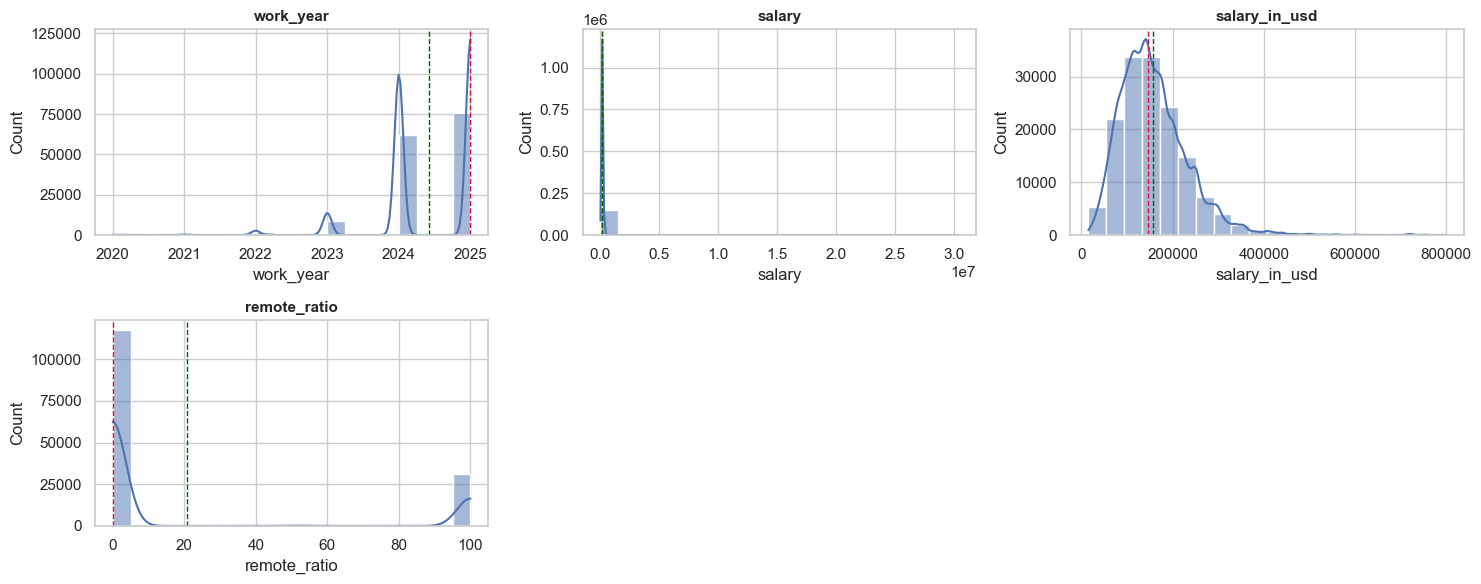

In [16]:
sns.set(style="whitegrid")

numerical_cols = df.select_dtypes(include=np.number).columns
n = len(numerical_cols)

# Calcular filas y columnas automáticamente
cols = 3
rows = (n // cols) + (n % cols > 0)

fig, axes = plt.subplots(rows, cols, figsize=(15, rows * 3))
axes = axes.flatten()

for i, col in enumerate(numerical_cols):
    sns.histplot(df[col], kde=True, bins=20, color='#4C72B0', ax=axes[i])
    axes[i].axvline(df[col].median(), color='crimson', linestyle='--', linewidth=1)
    axes[i].axvline(df[col].mean(), color='darkgreen', linestyle='--', linewidth=1)
    axes[i].set_title(f"{col}", fontsize=11, fontweight="bold")

# Eliminar ejes vacíos
for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()


#### Distribución de variables categóricas

C:\Users\eveli\AppData\Local\Temp\ipykernel_15232\3352384916.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(
C:\Users\eveli\AppData\Local\Temp\ipykernel_15232\3352384916.py:14: UserWarning: The palette list has more values (8) than needed (4), which may not be intended.
  ax = sns.countplot(
C:\Users\eveli\AppData\Local\Temp\ipykernel_15232\3352384916.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(
C:\Users\eveli\AppData\Local\Temp\ipykernel_15232\3352384916.py:14: UserWarning: The palette list has more values (8) than needed (4), which may not be intended.
  ax = sns.countplot(
C:\Users\eveli\AppData\Local\Temp\ipykernel_15232\3352384916.py:14: FutureWarning: 

P

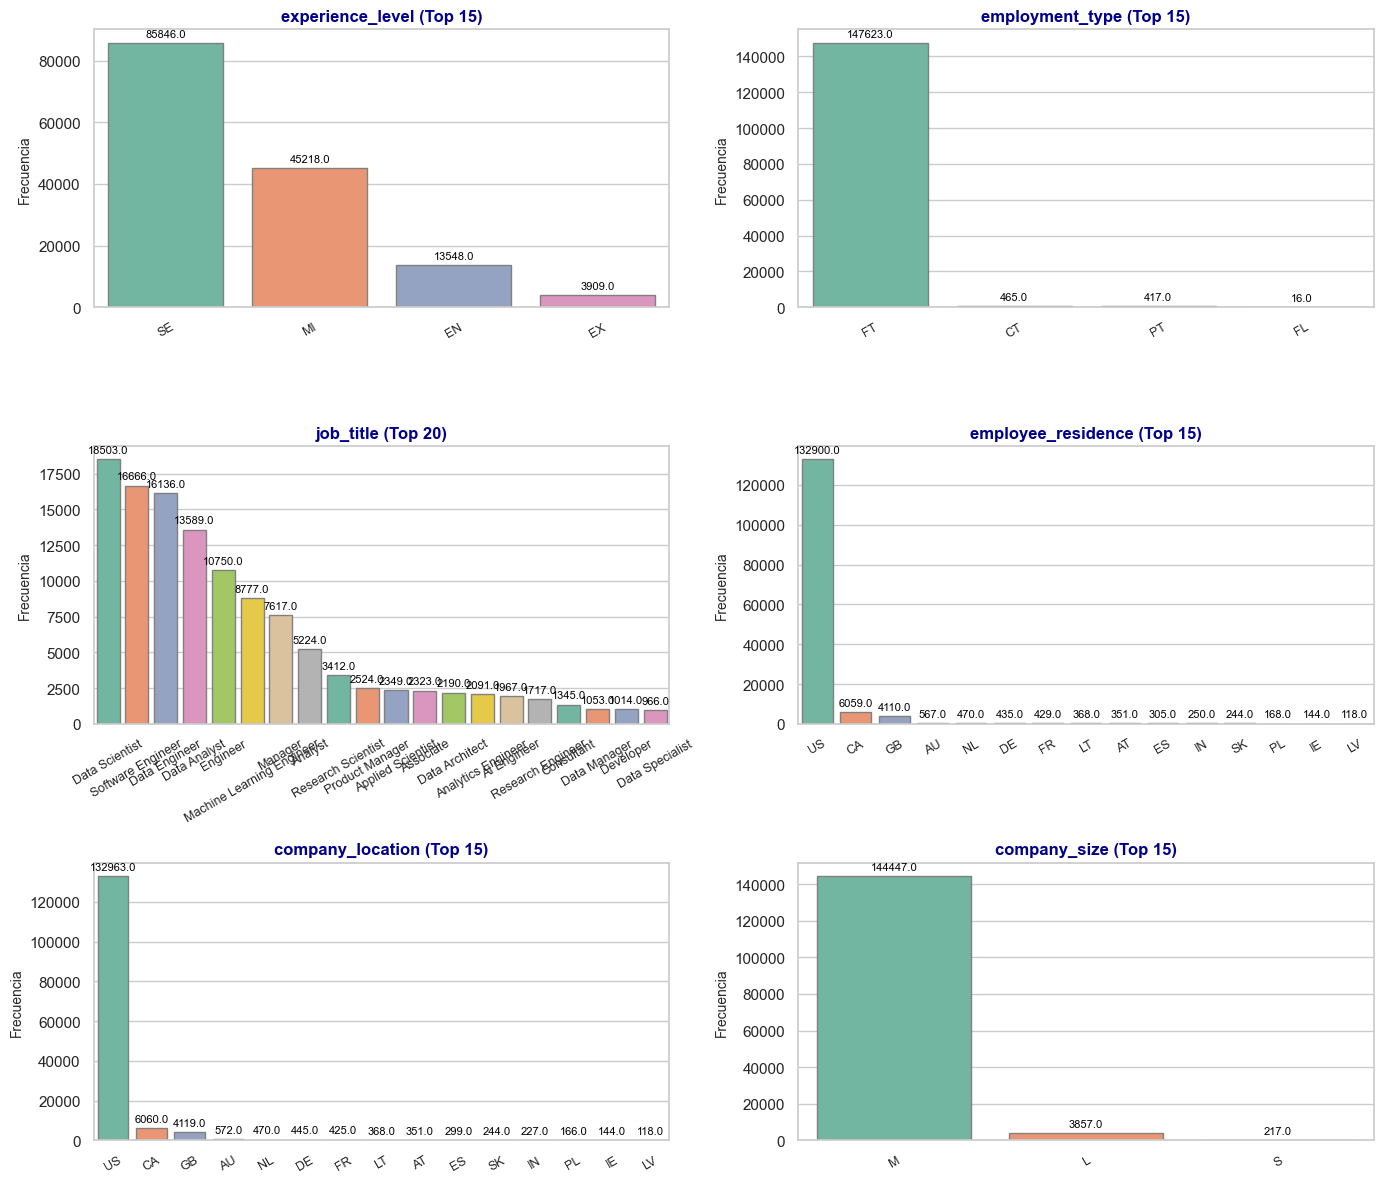

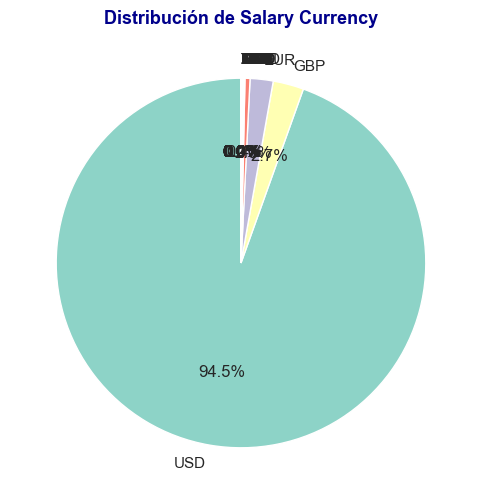

In [22]:

sns.set_style("whitegrid")
palette_cat = sns.color_palette("Set2")

# Función auxiliar: Top N
def plot_top_categories(df, col, top_n=15, ax=None):
    """
    Grafica un countplot con las Top N categorías más frecuentes.
    """
    top_values = df[col].value_counts().nlargest(top_n).index
    data = df[df[col].isin(top_values)]

    ax = sns.countplot(
        data=data,
        x=col,
        order=data[col].value_counts().index,
        palette=palette_cat,
        edgecolor='gray',
        ax=ax
    )

    ax.set_title(f'{col} (Top {top_n})', fontsize=12, fontweight='bold', color='darkblue')
    ax.set_xlabel("")
    ax.set_ylabel("Frecuencia", fontsize=10)
    ax.tick_params(axis='x', rotation=30, labelsize=9)

    # Etiquetas en las barras
    for bar in ax.patches:
        height = bar.get_height()
        if height > 0:
            ax.annotate(f'{height}', 
                        (bar.get_x() + bar.get_width()/2, height),
                        ha='center', va='bottom', fontsize=8,
                        color='black', xytext=(0, 3),
                        textcoords='offset points')

    return ax


# Gráficas categóricas
categorical_cols = df.select_dtypes(include='object').columns

# Ajustes para columnas específicas
special_top = {
    "job_title": 20,            
    "employee_residence": 15,   
    "company_location": 15      
}

# Excluir salary_currency (lo graficamos como pastel)
categorical_cols = [c for c in categorical_cols if c != "salary_currency"]

n = len(categorical_cols)
cols = 2
rows = (n // cols) + (n % cols > 0)

fig, axes = plt.subplots(rows, cols, figsize=(14, rows * 4))
axes = axes.flatten()

for i, col in enumerate(categorical_cols):
    top_n = special_top.get(col, 15)  # por defecto Top 15
    plot_top_categories(df, col, top_n=top_n, ax=axes[i])

# Eliminar ejes sobrantes
for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()


# Gráfico de Salary Currency

currency_counts = df["salary_currency"].value_counts()

plt.figure(figsize=(6,6))
plt.pie(currency_counts.values, labels=currency_counts.index,
        autopct='%1.1f%%', colors=sns.color_palette("Set3"), startangle=90)
plt.title("Distribución de Salary Currency", fontsize=13, fontweight="bold", color="darkblue")
plt.show()


### Tasa anual de contratación de profesionales en ciencia de datos

In [23]:
df['work_year'].value_counts()

work_year
2025    75802
2024    62241
2023     8524
2022     1661
2021      218
2020       75
Name: count, dtype: int64

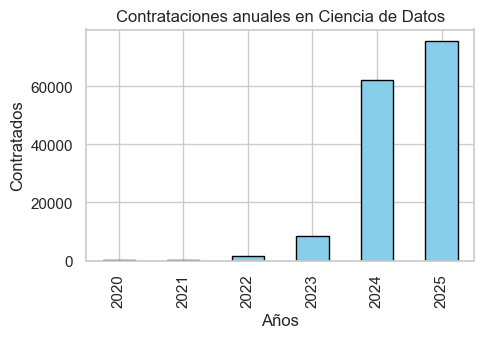

In [25]:
df['work_year'].value_counts().sort_index().plot.bar(
    figsize=(5,3), color="skyblue", edgecolor="black"
)
plt.xlabel("Años")
plt.ylabel("Contratados")
plt.title("Contrataciones anuales en Ciencia de Datos")
plt.show()

La mayoría de los registros corresponden a los años más recientes (2024 y 2025), indicando que los datos son predominantemente actuales.

#### Impacto del nivel de experiencia en las oportunidades de empleo cada año

In [26]:
df.groupby('work_year')['experience_level'].value_counts()

work_year  experience_level
2020       MI                     31
           EN                     21
           SE                     19
           EX                      4
2021       MI                     87
           SE                     75
           EN                     46
           EX                     10
2022       SE                   1142
           MI                    359
           EN                    117
           EX                     43
2023       SE                   6097
           MI                   1717
           EN                    466
           EX                    244
2024       SE                  35331
           MI                  19534
           EN                   6185
           EX                   1191
2025       SE                  43182
           MI                  23490
           EN                   6713
           EX                   2417
Name: count, dtype: int64

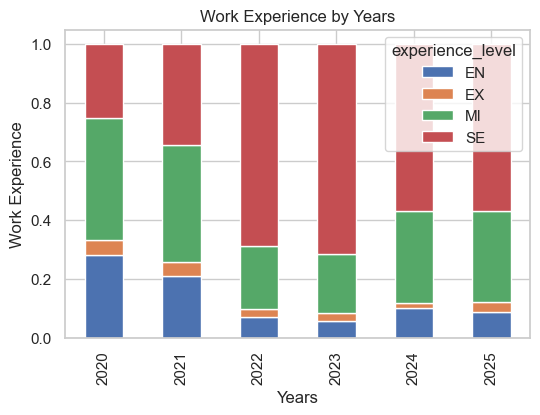

In [28]:
df_counts = df.groupby('work_year')['experience_level'].value_counts().unstack(fill_value=0)
df_props = df_counts.div(df_counts.sum(axis=1), axis=0)

df_props.plot(kind='bar', stacked=True, figsize=(6,4))
plt.xlabel('Years')
plt.ylabel('Work Experience')
plt.title('Work Experience by Years')
plt.show()


Se puede evidenciar que el mercado de Ciencia de Datos favorece perfiles Senior y Mid-level, pero sigue abriendo espacio para entry-level, aunque en menor medida.

#### Cambio de salarios a lo largo del tiempo

In [29]:
df.groupby('work_year')['salary_in_usd'].mean()

work_year
2020    102250.866667
2021     99922.073394
2022    134146.471403
2023    153682.160371
2024    159589.557767
2025    156981.857471
Name: salary_in_usd, dtype: float64

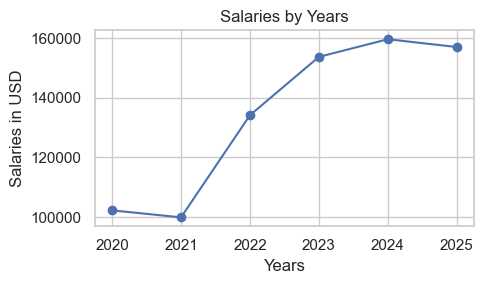

In [31]:
df.groupby('work_year')['salary_in_usd'].mean().plot.line(figsize=(5,3), marker='o')
plt.xlabel('Years')
plt.ylabel('Salaries in USD')
plt.title('Salaries by Years')
plt.tight_layout()
plt.show()


Después de una ligera caída en 2021, los salarios han mostrado una tendencia creciente hasta 2024, con una leve disminución en 2025.

#### Distribución salarial según el nivel de experiencia

In [32]:
df.groupby('experience_level')['salary_in_usd'].mean()

experience_level
EN     98902.747121
EX    202364.660271
MI    142443.913397
SE    172667.352294
Name: salary_in_usd, dtype: float64

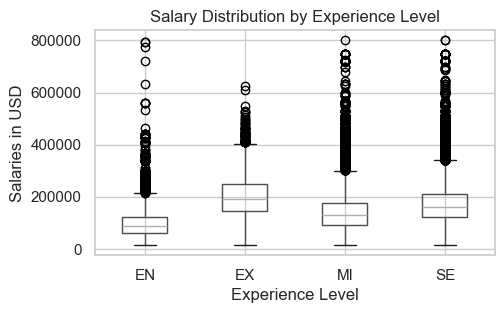

In [33]:
df.boxplot(column='salary_in_usd', by='experience_level', figsize=(5,3))
plt.title('Salary Distribution by Experience Level')
plt.suptitle('')
plt.xlabel('Experience Level')
plt.ylabel('Salaries in USD')
plt.show()


Los resultados muestran que el nivel de experiencia tiene un impacto claro en los salarios promedio.


#### Salarios según el tipo de empleo

In [34]:
df.groupby('employment_type')['salary_in_usd'].mean()

employment_type
CT    104928.161290
FL     50651.562500
FT    157925.442018
PT     76207.983213
Name: salary_in_usd, dtype: float64

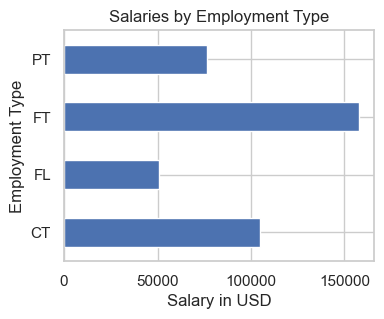

In [35]:
df.groupby('employment_type')['salary_in_usd'].mean().plot.barh(figsize=(4,3))
plt.xlabel('Salary in USD')
plt.ylabel('Employment Type')
plt.title('Salaries by Employment Type')
plt.show()


se puede observar que los profesionales a tiempo completo son quienes reciben los salarios más altos en promedio, mientras que los freelancers y los de medio tiempo ganan bastante menos.

#### Títulos de trabajo con los salarios promedios más altos

In [36]:
df.groupby('job_title')['salary_in_usd'].median().sort_values(ascending = False).head(7)

job_title
Research Team Lead               450000.0
Analytics Engineering Manager    399880.0
Data Science Tech Lead           375000.0
Applied AI ML Lead               292500.0
IT Enterprise Data Architect     284090.0
Head of Applied AI               281500.0
AIRS Solutions Specialist        263250.0
Name: salary_in_usd, dtype: float64

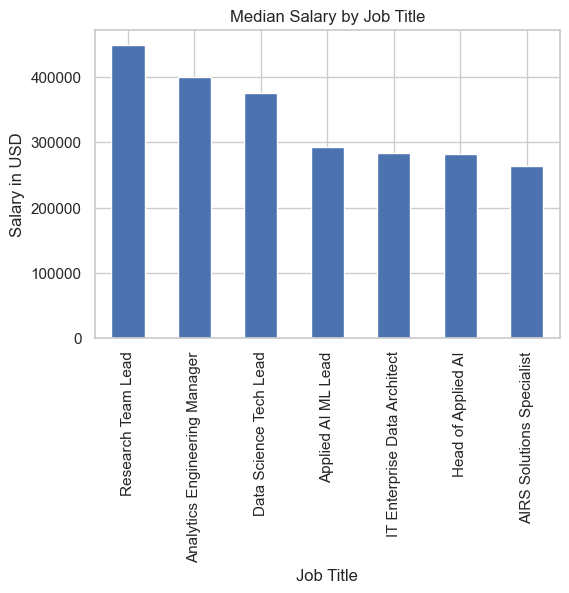

In [38]:
df.groupby('job_title')['salary_in_usd'].median().sort_values(ascending=False).head(7).plot.bar(figsize=(6,4))
plt.xlabel('Job Title')
plt.ylabel('Salary in USD')
plt.title('Median Salary by Job Title')
plt.show()

Nos confirma que los puestos de liderazgo y gestión en ciencia de datos, analítica e inteligencia artificial son los que concentran los salarios más altos.

### Los títulos de trabajo más comunes


In [39]:
df['job_title'].value_counts().head(7)

job_title
Data Scientist               18503
Software Engineer            16666
Data Engineer                16136
Data Analyst                 13589
Engineer                     10750
Machine Learning Engineer     8777
Manager                       7617
Name: count, dtype: int64

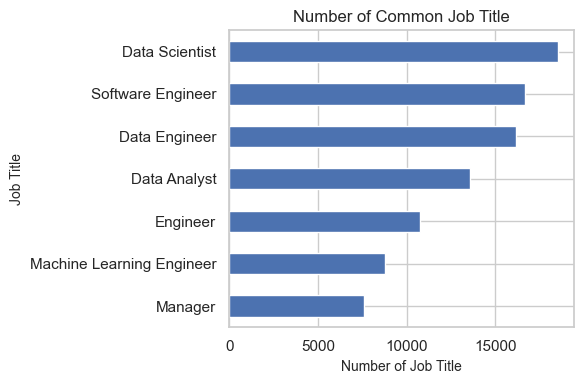

In [40]:
plt.figure(figsize=(6,4))
df['job_title'].value_counts().head(7).sort_values().plot.barh()
plt.ylabel('Job Title', fontsize=10)
plt.xlabel('Number of Job Title', fontsize=10)
plt.title('Number of Common Job Title', fontsize=12)
plt.tight_layout()
plt.show()

Los roles más comunes están relacionados con ciencia de datos, ingeniería de software y análisis de datos, siendo Data Scientist el más frecuente

### Impacto del trabajo remoto en el salario

In [41]:
df.groupby('remote_ratio')['salary_in_usd'].mean()

remote_ratio
0      159331.619628
50      81556.387195
100    151429.741945
Name: salary_in_usd, dtype: float64

In [42]:
remote_salary = df.groupby('remote_ratio')['salary_in_usd'].mean()
remote_salary = remote_salary.rename({
    0: 'On-site',
    50: 'Hybrid',
    100: 'Fully Remote'
})
print(remote_salary)

remote_ratio
On-site         159331.619628
Hybrid           81556.387195
Fully Remote    151429.741945
Name: salary_in_usd, dtype: float64


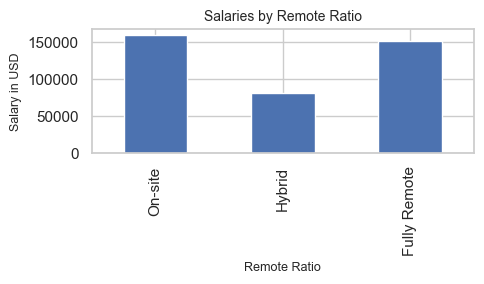

In [43]:
plt.figure(figsize=(5,3))
remote_salary.plot.bar()
plt.xlabel('Remote Ratio', fontsize=9)
plt.ylabel('Salary in USD', fontsize=9)
plt.title('Salaries by Remote Ratio', fontsize=10)
plt.tight_layout()
plt.show()

los trabajos totalmente presenciales (On-site) y completamente remotos (Fully Remote) tienen salarios promedio más altos, mientras que los puestos híbridos (Hybrid) presentan un salario promedio significativamente menor.

### Influencia del tamaño de la empresa en el salario

In [44]:
df.groupby('company_size')['salary_in_usd'].mean()

company_size
L    159269.698470
M    157576.445326
S     87835.258065
Name: salary_in_usd, dtype: float64

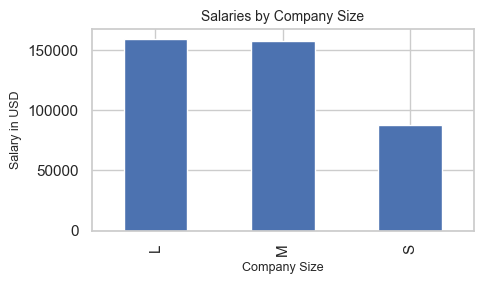

In [45]:
plt.figure(figsize=(5,3))
df.groupby('company_size')['salary_in_usd'].mean().plot.bar()
plt.xlabel('Company Size', fontsize=9)
plt.ylabel('Salary in USD', fontsize=9)
plt.title('Salaries by Company Size', fontsize=10)
plt.tight_layout()
plt.show()

Se observa que las empresas grandes (L) y medianas (M) ofrecen salarios promedio significativamente más altos que las pequeñas (S).

### Relación entre el tamaño de la empresa y la contratación de empleados remotos

In [46]:
df.groupby('company_size')['remote_ratio'].value_counts()

company_size  remote_ratio
L             0                 3254
              100                389
              50                 214
M             0               114035
              100              30342
              50                  70
S             100                119
              0                   54
              50                  44
Name: count, dtype: int64

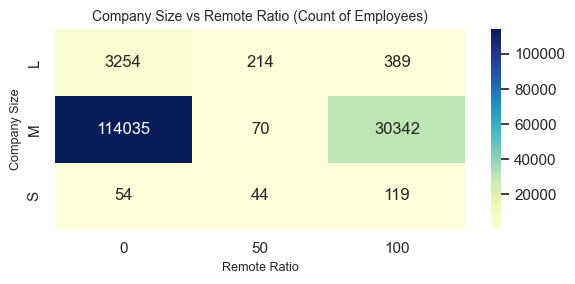

In [47]:
plt.figure(figsize=(6,3))
counts = df.groupby('company_size')['remote_ratio'].value_counts().unstack(fill_value=0)
sns.heatmap(counts, annot=True, fmt="d", cmap="YlGnBu")
plt.title('Company Size vs Remote Ratio (Count of Employees)', fontsize=10)
plt.ylabel('Company Size', fontsize=9)
plt.xlabel('Remote Ratio', fontsize=9)
plt.tight_layout()
plt.show()

Las empresas más grandes tienden a tener más empleados presenciales, mientras que las pequeñas muestran una proporción relativamente mayor de trabajadores totalmente remotos.

#### Matriz de correlación

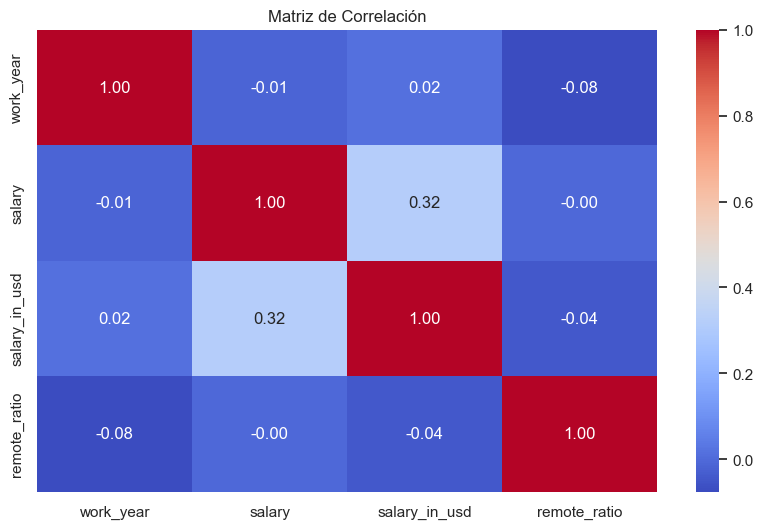

In [ ]:

plt.figure(figsize=(10, 6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Matriz de Correlación')
plt.show()


La matriz de correlación muestra que salary y salary_in_usd están moderadamente relacionadas, mientras que remote_ratio y work_year presentan correlaciones bajas con las demás variables, lo que sugiere que no hay evidencia clara de que la modalidad de trabajo remoto o el año del registro influyan en el salario.